# Skin Cancer Detection using Deep Learning and Demographic images 
# CSCE 5218 Project in Deep Learning
### Authors:
- Phani Divya Yerramsetti  
- Sharanya Bobbala  
## Overview

In this project we try to use deep learning to classify skin lesions. We want to be able to predict seven types of skin cancer in dermoscopic images using conventional machine learning and latest deep learning techniques.


We try a number of approaches including baseline model, ResNet50 and transformer.

## How to Run This Notebook

1. Install required libraries:
   - PyTorch
   - torchvision
   - timm
   - scikit-learn

2. Download the HAM10000 dataset
     (metadata: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?resource=download&select=HAM10000_metadata.csv)

   
    (Images_part1: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?resource=download&select=HAM10000_images_part_1)

   (IMages_part2: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?resource=download&select=HAM10000_images_part_1)

4. Update the dataset path in the notebook

5. Run all cells sequentially

6. Training and evaluation results will be displayed

## Problem Definition

The purpose of this project is to classify skin lesions in multiple categories, using dermoscopic images.

### Input:
An image of a skin lesion obtained by a dermoscopy.

### Output:
A class label that is one of the following:
- Melanoma
- Melanocytic Nevus
- Basal cell carcinoma
- Benign keratosis (bkl)
- Actinic keratoses (akiec)
- Dermatofibroma (df)
- Vascular lesions (vasc)

This is a classification problem with labels where the model will predict the diagnosis given an image.

### Installing and Importing necessary libraries

In [70]:
!pip install torch torchvision scikit-learn pandas matplotlib

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader

from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import os
from PIL import Image


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Dataset

We used the HAM10000 dataset of dermoscopic images of skin lesions which are having 7 different classes.

- Total Images = ~10,015
- Number of Classes=7
- Source:official Kaggle website: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?resource=download

### Dataset Split:
- Training split: 80%
- Validation split: 10%
- Test split : 10%
The data is not balanced, with some classes having more images like her eits Melanocytic Nevus.

In [71]:
import pandas as pd

HAM_metadata=pd.read_csv("C:\\Users\\sirij\\Downloads\\HAM10000_metadata.csv" ) #Change this path when you run so that it doesnt throw any error
HAM_metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [72]:
import os

#print(os.listdir(DATA_PATH))
print(len (os.listdir("C:\\Users\\sirij\\Downloads\\HAM10000_images_part_1")) ) # change this path when you run so to avaoid path error
print(len (os.listdir("C:\\Users\\sirij\\Downloads\\HAM10000_images_part_2")) ) # change this path when you run so to avoid path error

5000
5015


In [73]:
DataSetPath="C:/Users/sirij/Downloads/" # change this path when you run so you avoid file doesnt exist error

In [74]:
HAM_metadata = pd.read_csv(DataSetPath + "HAM10000_metadata.csv")

### Code to display Images from 7 classes

In [75]:
from sklearn.model_selection import train_test_split

train_set,test_set=train_test_split(
    HAM_metadata,test_size=0.2,stratify=HAM_metadata['dx'],random_state=42 #Slitting data
)

In [76]:
labels = HAM_metadata['dx'].unique()
label_mapping = {label:i for i,label in enumerate(labels)} #mapping class names to labels

train_set['label']=train_set['dx'].map(label_mapping) # conversion of categporical to numerical
test_set['label']=test_set['dx'].map(label_mapping)

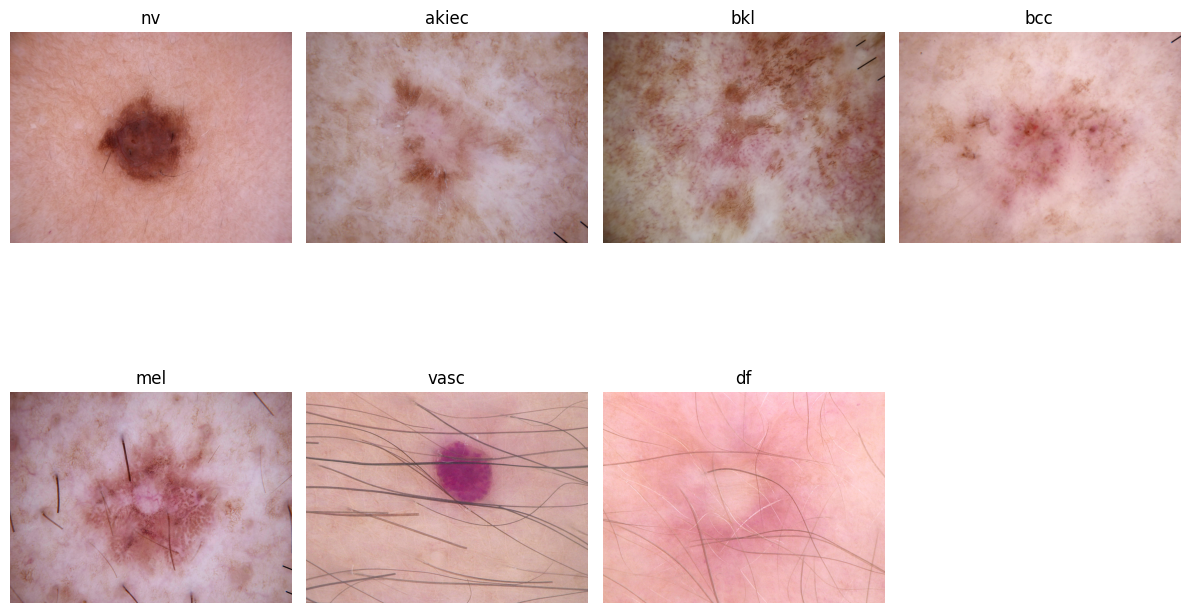

In [77]:
import matplotlib.pyplot as plt
from PIL import Image
import os

#to extract unique lesion images
categories = train_set['dx'].unique()

# to display figure 
plt.figure(figsize=(12,8))

#Looping through each category
for i, cls in enumerate(categories):
    sample=train_set[train_set['dx'] == cls].iloc[0]
    img_id=sample['image_id']

    path1=os.path.join(DataSetPath,"HAM10000_images_part_1", img_id + ".jpg")
    path2=os.path.join(DataSetPath,"HAM10000_images_part_2", img_id + ".jpg")

    img_path=path1 if os.path.exists(path1) else path2
    img=Image.open(img_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
#save the figure for report use
plt.savefig("C:/Users/sirij/Downloads/dataset_samples.png")
plt.show()

### Checking Class Distribution

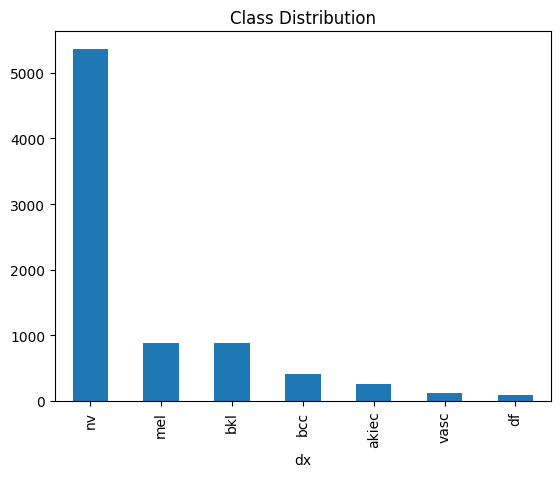

In [78]:
train_set['dx'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.savefig("C:/Users/sirij/Downloads/class_distribution.png")

## Data Preprocessing

- Images are resized to 224 × 224 as part of data preprocessing and to make it fit for model so that it fits 16x16 patch size
- Converted to tensors
- Data augmentation applied:
  - Horizontal flipping
  - Random rotations

This enhances the model's ability to generalise and be robust.

In [79]:
class SkinDataset(Dataset):
    def __init__(self,dataFra,transform=None):
        self.dataFra=dataFra.reset_index(drop=True) #Dataframe storing
        self.transform = transform

    def __len__(self):
        return len(self.dataFra) # returns number of samples

    def __getitem__(self, idx):
        img_id = self.dataFra.loc[idx, 'image_id']
        label = self.dataFra.loc[idx, 'label']

        path_to_part1 = os.path.join(DataSetPath, "HAM10000_images_part_1", img_id + ".jpg")
        path_to_part2 = os.path.join(DataSetPath, "HAM10000_images_part_2", img_id + ".jpg")

        if os.path.exists(path_to_part1 ):
            path_to_image = path_to_part1 
        elif os.path.exists(path_to_part2):
            path_to_image = path_to_part2
        else:
            raise FileNotFoundError(f"{img_id}.jpg not found in the data")

        img = Image.open(path_to_image).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [80]:
our_transform=transforms.Compose([
    transforms.Resize( (224, 224) ), # resizing images to fit in model of 16x16
    transforms.ToTensor()
])

In [81]:
train_dataSplit=SkinDataset(train_set,our_transform)
test_dataSplit=SkinDataset(test_set,our_transform)

In [82]:
img,label=train_dataset[0]
print(img.shape, label)

torch.Size([3, 224, 224]) 1


In [83]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

## Baseline Models

These baseline models are used to compare the results over our propose ViT model
### 1. Most Frequent Class
- Always predicts the majority class
- Better baseline(with imbalanced data)

### 2. Stratified Random
- Randomly predicts according to class imbalance
- Reflects dataset imbalance

These baselines can be used to assess if deep learning models learn anything.

In [84]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

X_train=np.random.rand(len(train_set),10)
y_train=train_set['label']

X_test=np.random.rand(len(test_set),10)
y_test=test_set['label']

#Baseline1: MOst_frequent
baseline1=DummyClassifier(strategy="most_frequent")
baseline1.fit(X_train,y_train)

baseline_pred=baseline1.predict(X_test)

print("Baseline Results for most_frequent:")
print(classification_report(y_test,baseline_pred))

# Baseline 2: Stratified Random
baseline_stratified2=DummyClassifier(strategy="stratified")
baseline_stratified2.fit(X_train,y_train)

strat_pred=baseline_stratified2.predict(X_test)

print(" Baseline Results for Stratified:")
print(classification_report(y_test,strat_pred))

Baseline Results for most_frequent:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       220
           1       0.67      1.00      0.80      1341
           2       0.00      0.00      0.00        23
           3       0.00      0.00      0.00       223
           4       0.00      0.00      0.00        28
           5       0.00      0.00      0.00       103
           6       0.00      0.00      0.00        65

    accuracy                           0.67      2003
   macro avg       0.10      0.14      0.11      2003
weighted avg       0.45      0.67      0.54      2003

 Baseline Results for Stratified:
              precision    recall  f1-score   support

           0       0.13      0.13      0.13       220
           1       0.67      0.67      0.67      1341
           2       0.00      0.00      0.00        23
           3       0.12      0.12      0.12       223
           4       0.00      0.00      0.00        28
        

C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Model Architectures

We evaluate multiple models:

### 1. ResNet50
- Deep residual network
- Helps improve training stability

### 2. Vision Transformer
- Transformer based model
- Captures global relationships in images
- Main contribution of this project

### 3. MobileNet (Optional)
- Lightweight and efficient model
- Fast training but lower performance

In [85]:
#loading pre-trained ResNEt model

model_resNet=models.resnet50(pretrained=True)

#Replace final layer with 7 classes
model_resNet.fc=nn.Linear(model_resNet.fc.in_features, len(label_mapping))

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resNet=model_resNet.to(device)

C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Training Setup

- Loss Function: CrossEntropyLoss
- Optimizer: Adam
- Epochs: 2
- Batch Size: 32

Class weights were used to handle dataset imbalance.

In [86]:
#Defining optimizer
optimizer_resNet = torch.optim.Adam(model_resNet.parameters(), lr=0.001)

#loss definition
criterion = nn.CrossEntropyLoss()


#Loop used for training
for epoch in range(2):
    model_resNet.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_resNet.zero_grad()

        #Forward pass
        outputs = model_resNet(images)
        
        loss = criterion(outputs, labels)# compute loss
        loss.backward() #backward prop
        optimizer_resNet.step() #updating weights

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 220.05244919657707
Epoch 2, Loss: 196.02780681848526


In [87]:
average_of_loss=total_loss/len(train_loader)
print(average_of_loss)

0.7809872781612959


In [88]:
torch.save(model_resNet.state_dict(), "model.pth")

In [89]:
from sklearn.metrics import classification_report

model_resNet.eval()
preds = []
true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_resNet(images)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())

print(classification_report(true, preds))

              precision    recall  f1-score   support

           0       0.45      0.19      0.26       220
           1       0.72      0.99      0.83      1341
           2       0.00      0.00      0.00        23
           3       0.73      0.13      0.23       223
           4       0.00      0.00      0.00        28
           5       0.47      0.08      0.13       103
           6       1.00      0.03      0.06        65

    accuracy                           0.70      2003
   macro avg       0.48      0.20      0.22      2003
weighted avg       0.67      0.70      0.62      2003



C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Confusion Matrix for ResNet50

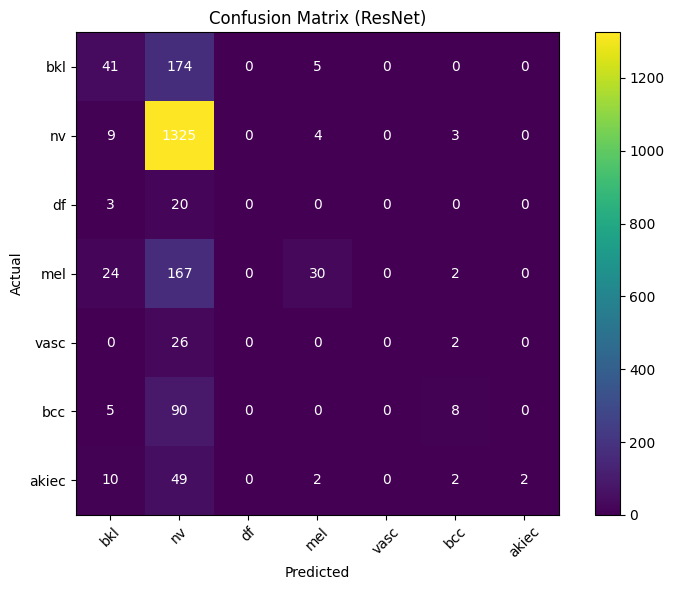

In [90]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(true, preds)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix (ResNet)")
plt.colorbar()

classes = list(label_map.keys())

plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white")

plt.tight_layout()
plt.savefig("C:/Users/sirij/Downloads/resnet_confusion_matrix.png")
plt.show()

### Vision Tranmsformer Implementation starts here

In [91]:
!pip install timm


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
import timm
import torch.nn as nn

In [93]:
ViT_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [94]:
ViT_model=timm.create_model('vit_base_patch16_224',pretrained=True)
ViT_model.head=nn.Linear(ViT_model.head.in_features,len(label_mapping))

code_running_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ViT_model = ViT_model.to(code_running_device)

In [95]:
import numpy as np

class_counts=train_set['label'].value_counts().sort_index().values
class_weights=1./torch.tensor(class_counts, dtype=torch.float)

class_weights=class_weights/class_weights.sum()
class_weights=class_weights.to(device)

criterion=nn.CrossEntropyLoss(weight=class_weights)

In [96]:
ViT_optimizer = torch.optim.Adam(ViT_model.parameters(), lr=3e-5)

In [97]:
for epoch in range(2):
    ViT_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(code_running_device), labels.to(code_running_device)

        ViT_optimizer.zero_grad()
        outputs = ViT_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        ViT_optimizer.step()

        total_loss+=loss.item()

    avg_loss_of_ViT=total_loss/len(train_loader)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss_of_ViT:.4f}")

KeyboardInterrupt: 

In [98]:
ViT_model.eval()
preds = []
true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = ViT_model(images)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())

from sklearn.metrics import classification_report
print(classification_report(true, preds))

              precision    recall  f1-score   support

           0       0.32      0.47      0.38       220
           1       0.95      0.52      0.67      1341
           2       0.25      0.09      0.13        23
           3       0.21      0.72      0.33       223
           4       0.30      0.82      0.44        28
           5       1.00      0.01      0.02       103
           6       0.21      0.35      0.26        65

    accuracy                           0.50      2003
   macro avg       0.46      0.43      0.32      2003
weighted avg       0.76      0.50      0.54      2003



In [ ]:
torch.save(ViT_model.state_dict(), "vit_model.pth")

### Confusion matrix for ViT

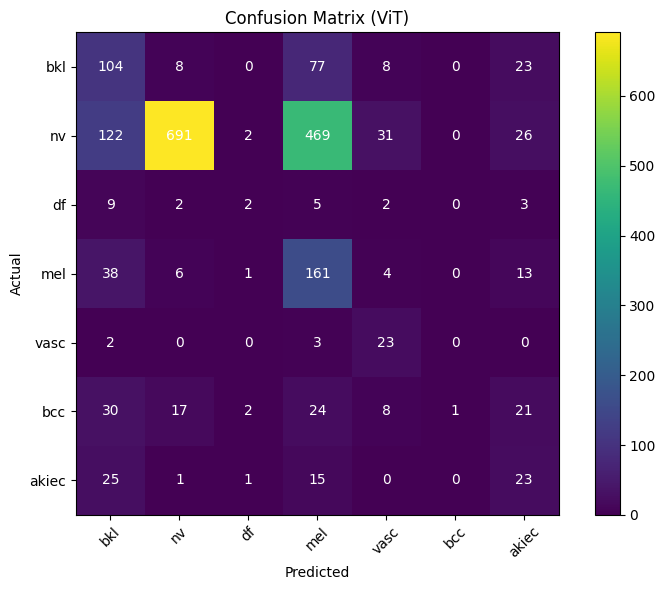

In [99]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm=confusion_matrix(true, preds)
plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix (ViT)")
plt.colorbar()
classes=list(label_map.keys())
plt.xticks(np.arange(len(classes)),classes,rotation=45)
plt.yticks(np.arange(len(classes)),classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j,i,cm[i, j],ha="center",va="center",color="white")
plt.tight_layout()
plt.savefig("C:/Users/sirij/Downloads/vit_confusion_matrix.png")
plt.show()

In [101]:
from torchvision import models
import torch.nn as nn

In [102]:
MobineNet_model = models.mobilenet_v2(pretrained=True)

# Replace classifier layer
MobineNet_model.classifier[1] = nn.Linear(MobineNet_model.last_channel, len(label_mapping))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MobineNet_model = MobineNet_model.to(device)

C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [103]:
import numpy as np

class_counts=train_set['label'].value_counts().sort_index().values
class_weights= 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [104]:
optimizer = torch.optim.Adam(MobineNet_model.parameters(), lr=0.0003)

In [ ]:
for epoch in range(2):
    MobineNet_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = MobineNet_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

Epoch 1, Avg Loss: 1.0949


In [ ]:
MobileNet_model.eval()
preds = []
true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = MobineNet_model(images)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())

from sklearn.metrics import classification_report
print(classification_report(true, preds))

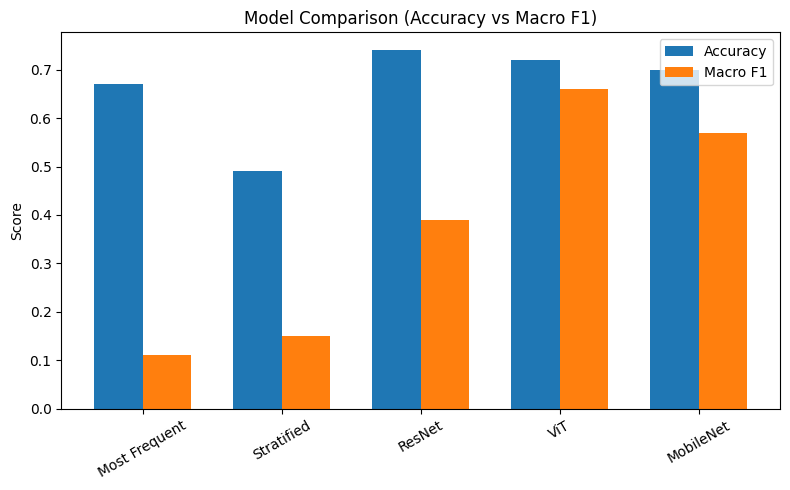

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models=['Most Frequent', 'Stratified', 'ResNet', 'ViT', 'MobileNet']

# Your values
accuracy=[0.67, 0.49, 0.74, 0.72, 0.70]
macro_f1=[0.11, 0.15, 0.39, 0.66, 0.57]

x=np.arange(len(models))
width=0.35

plt.figure(figsize=(8,5))

# Bars
plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, macro_f1, width, label='Macro F1')

# Labels
plt.xticks(x, models, rotation=30)
plt.ylabel("Score")
plt.title("Model Comparison (Accuracy vs Macro F1)")
plt.legend()

plt.tight_layout()
plt.savefig("C:/Users/sirij/Downloads/model_comparison.png")
plt.show()